## Passo 1: Importação de Bibliotecas e Leitura do Dataset

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo visual dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

# Leitura do dataset
df = pd.read_csv(r'C:\Users\pablo\Documents\vs code projetos\visualizacao dados\ecommerce_estatistica.csv')
df.head()

,Unnamed: 0,Título,Nota,N_Avaliações,Desconto,Marca,Material,Gênero,Temporada,Review1,...,Nota_MinMax,N_Avaliações_MinMax,Desconto_MinMax,Preço_MinMax,Marca_Cod,Material_Cod,Temporada_Cod,Qtd_Vendidos_Cod,Marca_Freq,Material_Freq
0,1,Kit 10 Cuecas Boxer Lupo Cueca Box Algodão Mas...,4.5,3034.0,18.0,lupo,algodão,Masculino,outono/inverno,As cuecas são boas; porém você percebe na cost...,...,0.814815,0.334178,0.213115,0.378585,463,25,3,10000.0,0.042292,0.176444
1,2,Kit Com 10 Cuecas Boxer Algodão Sem Costura Zo...,4.7,5682.0,20.0,zorba,algodão,Masculino,não definido,O tecido é bom e são confortáveis. Só que a nu...,...,0.888889,0.625937,0.245902,0.322329,838,25,1,50000.0,0.009095,0.176444
2,3,Kit 10 Cuecas Boxer Mash Algodão Cotton Box Or...,4.6,1700.0,22.0,mash,algodão,Masculino,primavera/verão,"As cuecas são boas, porém meu marido usa g e p...",...,0.851852,0.187197,0.278689,0.372617,494,25,7,10000.0,0.010914,0.176444
3,4,Kit 3 Short Jeans Feminino Cintura Alta Barato...,4.4,507.0,9.0,menina linda,jean,Feminino,primavera/verão,Estou encantada com essas peças!.\nOs shorts s...,...,0.777778,0.055751,0.065574,0.201767,509,74,7,1000.0,0.010005,0.025466
4,5,Blusa + Calça Térmica Treino Futebol Criança I...,4.7,58.0,5.0,roupa zero grau,termico unissex,Sem gênero infantil,outono/inverno,"Produto ótimo , mesmo após várias lavagens não...",...,0.888889,0.006280,0.000000,0.114508,669,166,3,100.0,0.002274,0.000910


## Passo 2: Análise Exploratória e Estatística dos Dados
Verificação das informações gerais, tipos de dados e estatísticas descritivas.

In [8]:
# Resumo estatístico das colunas numéricas
print(df[['Preço', 'Nota', 'N_Avaliações', 'Desconto']].describe())

# Contagem de produtos por gênero
print(df['Gênero'].value_counts())

# Materiais mais populares
print(df['Material'].value_counts().head(10))

            Preço        Nota  N_Avaliações    Desconto
count  295.000000  295.000000    295.000000  295.000000
mean   130.836644    4.480678    490.511864   16.013559
std     64.232780    0.321243   1079.395818    9.928305
min     25.630000    2.300000      3.000000    5.000000
25%     73.340000    4.300000     19.000000    9.000000
50%    129.210000    4.500000     77.000000   11.000000
75%    179.900000    4.700000    326.000000   22.000000
max    326.550000    5.000000   9077.000000   51.000000
Gênero
Masculino                            129
Feminino                             114
Sem gênero                            25
Meninos                               13
Meninas                                6
Sem gênero infantil                    4
Bebês                                  2
Unissex                                1
roupa para gordinha pluss P ao 52      1
Name: count, dtype: int64
Material
algodão              113
poliéster             54
microfibra            23
jean      

## Passo 3: Criação das Visualizações de Dados

### 1. Gráfico de Histograma (Distribuição de Preços)

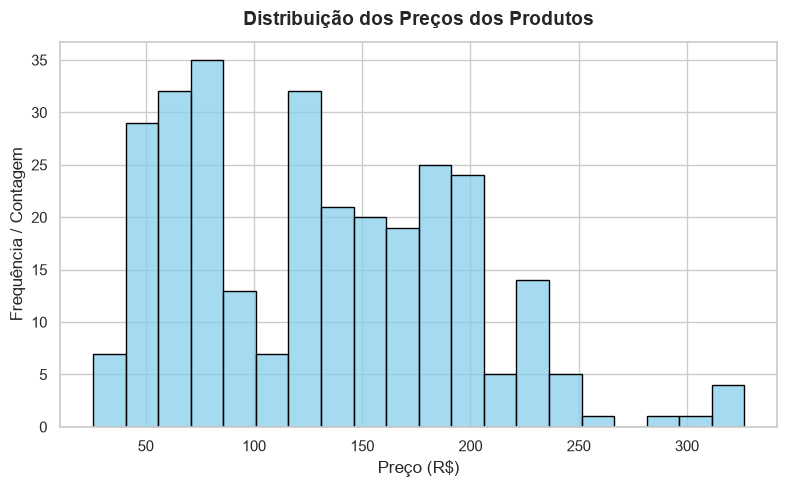

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Preço'], bins=20, kde=False, color='skyblue', edgecolor='black')
plt.title('Distribuição dos Preços dos Produtos', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Preço (R$)', fontsize=12)
plt.ylabel('Frequência / Contagem', fontsize=12)
plt.tight_layout()
plt.show()

### 2. Gráfico de Dispersão (Preço vs. Nº de Avaliações)

In [4]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Preço', y='N_Avaliações', hue='Gênero', alpha=0.8, palette='Set2', s=70)
plt.title('Relação entre Preço e Número de Avaliações', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Preço (R$)', fontsize=12)
plt.ylabel('Número de Avaliações (Escala Log)', fontsize=12)
plt.yscale('log')
plt.tight_layout()
plt.show()

### 3. Mapa de Calor (Correlação entre Métricas)

In [5]:
plt.figure(figsize=(8, 6))
cols_corr = ['Nota', 'N_Avaliações', 'Desconto', 'Preço', 'Qtd_Vendidos_Cod']
corr_matrix = df[cols_corr].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='Blues', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Mapa de Calor - Correlação entre Métricas', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

### 4. Gráfico de Barra (Top Materiais Mais Frequentes)

In [6]:
plt.figure(figsize=(9, 5))
top_materiais = df['Material'].value_counts().head(8)
sns.barplot(x=top_materiais.values, y=top_materiais.index, palette='viridis')
plt.title('Top 8 Materiais Mais Frequentes nos Produtos', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Quantidade de Produtos', fontsize=12)
plt.ylabel('Material', fontsize=12)
plt.tight_layout()
plt.show()

### 5. Gráfico de Pizza (Proporção por Gênero Target)

In [7]:
plt.figure(figsize=(7, 7))
genero_counts = df['Gênero'].value_counts()
plt.pie(genero_counts, labels=genero_counts.index, autopct='%1.1f%%', startangle=140, 
        colors=sns.color_palette('pastel')[0:len(genero_counts)], explode=[0.03]*len(genero_counts))
plt.title('Distribuição de Produtos por Gênero Target', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

### 6. Gráfico de Densidade (Curva de Probabilidade do Desconto)

In [8]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='Desconto', fill=True, color='teal', alpha=0.5, linewidth=2)
plt.title('Curva de Densidade de Probabilidade do Desconto (%)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Percentual de Desconto (%)', fontsize=12)
plt.ylabel('Densidade', fontsize=12)
plt.tight_layout()
plt.show()

### 7. Gráfico de Regressão (Tendência Desconto vs. Preço)

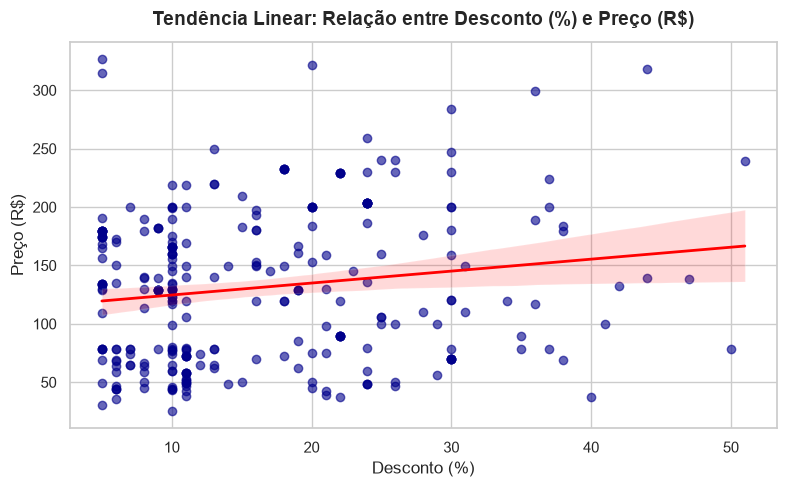

In [10]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='Desconto', y='Preço', scatter_kws={'alpha':0.6, 'color':'darkblue'}, line_kws={'color':'red', 'linewidth':2})
plt.title('Tendência Linear: Relação entre Desconto (%) e Preço (R$)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Desconto (%)', fontsize=12)
plt.ylabel('Preço (R$)', fontsize=12)
plt.tight_layout()
plt.show()